## 5.4 분산 양자 컴퓨팅 (Distributed Quantum Computing)

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 시뮬레이터 초기화
simulator = AerSimulator()

In [3]:
# 큐비트 3개 + 고전 비트 2개로 양자 회로 생성
qc = QuantumCircuit(3, 2)

In [4]:
# 1단계: 큐비트 1과 큐비트 2 사이에 얽힘쌍 생성
qc.h(1)
qc.cx(1, 2)

In [5]:
# 2단계: 옮길 큐비트(큐비트 0)를 임의 상태로 준비
qc.u(0.3, 0.2, 0.1, 0)  # 큐비트 0의 임의 상태 준비

In [6]:
# 3단계: 옮길 큐비트를 큐비트 1과 얽기
qc.cx(0, 1)
qc.h(0)

In [7]:
# 4단계: 큐비트 0과 큐비트 1 측정
qc.measure([0, 1], [0, 1])

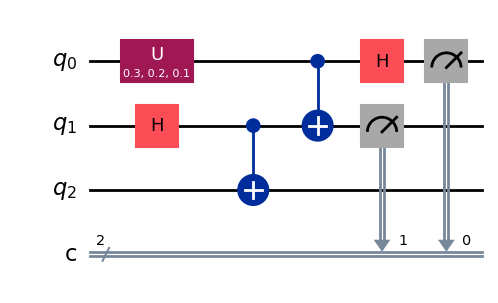

In [8]:
# 양자 회로 그리기
qc.draw('mpl')
plt.show()

In [9]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)

In [10]:
# 회로를 시뮬레이션해 측정 결과 얻기
result = simulator.run(compiled_circuit).result()

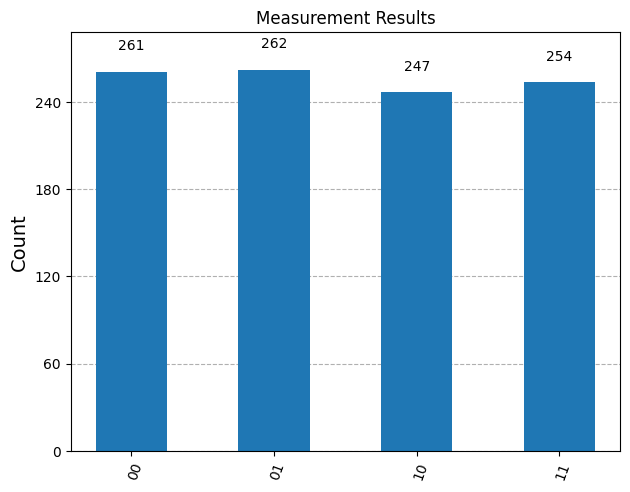

In [11]:
# 측정 결과를 얻어 그리기
counts = result.get_counts(compiled_circuit)
plot_histogram(counts)
plt.title("Measurement Results")
plt.show()

In [12]:
# 이제 측정 없는 같은 회로로 상태벡터를 얻는다
qc_no_measure = QuantumCircuit(3)

In [13]:
# 측정 직전까지의 연산을 반복 (보정 게이트 포함)
qc_no_measure.h(1)
qc_no_measure.cx(1, 2)
qc_no_measure.u(0.3, 0.2, 0.1, 0)
qc_no_measure.cx(0, 1)
qc_no_measure.h(0)
qc_no_measure.cx(1, 2)
qc_no_measure.cz(0, 2)

In [14]:
# 최종 상태의 상태벡터 얻기
statevector = Statevector.from_instruction(qc_no_measure)

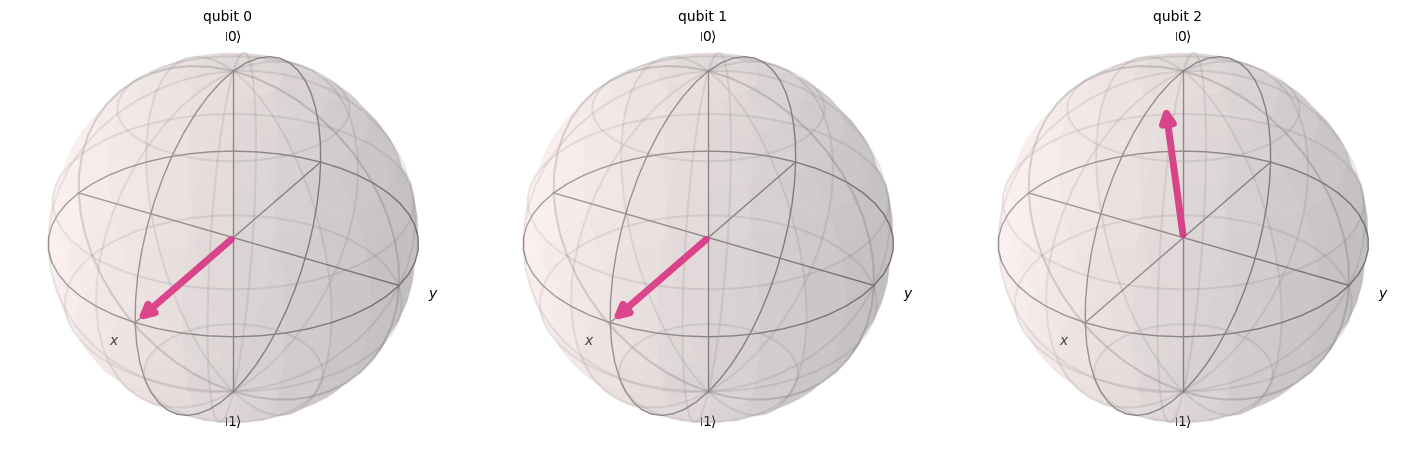

In [15]:
# 최종 상태를 블로흐 구로 그리기
plot_bloch_multivector(statevector)
plt.show()